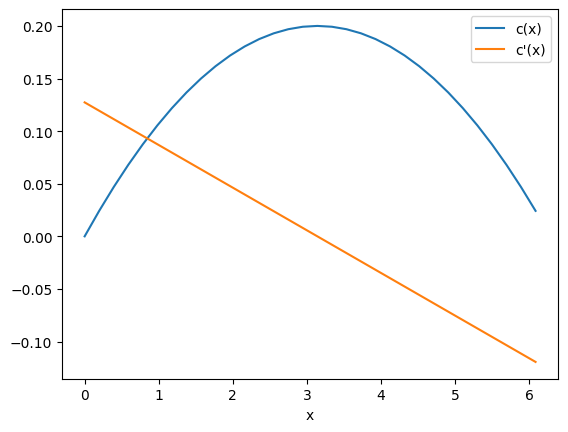

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 2 * np.pi               
t = 5     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 


plt.plot(x, c, label='c(x)')
plt.plot(x, cx, label='c\'(x)')
plt.xlabel('x')
plt.legend()

In [3]:
# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

# Parameters
D = 0.1
N = 2**n_qubits
L = 2*np.pi              
t = 5            
final_time = t
eps_lchs = 1e-1
eps_quad = 1e-1
C = 1
x = np.linspace(0, L, N, endpoint=False)
dx = L / N



j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
P_1 = 1j * (2 * np.pi / L) * (k_indices)
qft, qft_inv = get_qft_mat(n_qubits)
Delta = qft_inv @ np.diag(P_1) @ qft 

H_skew = Delta @ np.diag(c) + np.diag(c) @ Delta

# Hamiltonian
j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
Hamiltonian_diag = D * (2 * np.pi / L)**2 * (k_indices**2)

H_herm = np.diag(cx/2) + qft_inv @ np.diag(Hamiltonian_diag) @ qft

print(H_herm.shape)


(32, 32)


In [5]:

# LCHS Parameters 
norm=1
#norm = t * np.linalg.norm(Hamiltonian_diag, 2) # Use infinity norm for spectral bound?
h = np.pi / (norm/2 + np.log(64*np.exp(3*C/2)/(15*eps_quad)))
gamma = 1/C * np.sqrt(C+np.log((1+1/(2*np.pi))/eps_lchs))
R = 2*C*gamma**2
J = R/h
print(f"J :{J}")

J_int = int(2**(np.floor(np.log2(J)))) # closest power of 2 <= J
print(f"J_int :{J_int}")

R = J_int * h

print(f"R :{R}, h :{h}, gamma :{gamma}")
J = J_int
# LCU terms
num_terms = 2*J_int
n_ancilla = int(np.log2(num_terms))

# Compute Complex Weights
k = h*np.linspace(-J, J, num_terms)

weights = (h / np.sqrt(2*np.pi)) * np.exp(C*(1-1j*k)) * np.exp(-(k**2+1)/(4*gamma**2)) / (1 + k**2)

# 2. SEPARATE Magnitude and Phase 
magnitudes = np.abs(weights)
phases = np.angle(weights)

# 3. Prepare Amplitudes 
coeffs = np.sqrt(magnitudes)
coeffs = coeffs / np.linalg.norm(coeffs)         

# Build Circuit
reg_a = QuantumRegister(n_ancilla, 'ancilla') 
reg_s = QuantumRegister(n_qubits, 'system')
lc_qc = QuantumCircuit(reg_a, reg_s)

# PREP (Encodes magnitudes only)
prep_gate = StatePreparation(coeffs)
lc_qc.append(prep_gate, reg_a)

# SELECT (Encodes Unitary AND Phase)
for i in range(num_terms):
    # U(t; k) = exp(-i * k * H * t)
    # We multiply by the weight phase here: e^{i arg(w)} * U
    V = np.exp(1j * phases[i]) * expm(-1j * final_time * H_herm * k[i]-1* final_time / 2 * H_skew)
    # Qiskit endianness: format(i,...) puts LSB on right. 
    # DiagonalGate control matches this convention if applied correctly.
    ctrl_str = format(i, f'0{n_ancilla}b') 
    gate = UnitaryGate(V).control(n_ancilla, ctrl_state=ctrl_str)
    lc_qc.append(gate, list(reg_a) + list(reg_s))

# PREP Dagger (Uncompute)
lc_qc.append(prep_gate.inverse(), reg_a)

# Full Simulation Circuit
circuit = QuantumCircuit(n_ancilla + n_qubits)

# Initialize System (Gaussian)
sigma = L/20
state = np.exp(-0.25*((x-dx*N/2)/sigma)**2)
state = state / np.linalg.norm(state)
stateprep = StatePreparation(state)
circuit.append(stateprep, range(n_ancilla, n_ancilla + n_qubits))

# QFT -> LCU (Momentum Space) -> IQFT
circuit.compose(lc_qc, inplace=True)

# Simulation
final_state = Statevector(circuit)
full_data = np.array(final_state)

# Post-selection
system_state = full_data[0::2**n_ancilla]

# Normalize & Compare
success_prob = np.linalg.norm(system_state)**2
final = system_state / np.linalg.norm(system_state)

# Exact Solution (Finite Difference Approximation)
#A = (np.diag(-2 * np.ones(N)) + 
#     np.diag(1 * np.ones(N - 1), 1) + 
#     np.diag(1 * np.ones(N - 1), -1))
#A[0, N - 1] = 1
#A[N - 1, 0] = 1
#A = D * A / (dx**2)

#exact_final = expm(A * final_time) @ state
#exact_final = exact_final / np.linalg.norm(exact_final)

# Error Calculation
#err = np.linalg.norm(np.abs(exact_final) - np.abs(final))

print(f"Success Probability: {success_prob:.4e}")
#print(f"Error: {err:.4e}")

plt.figure()
plt.plot(x, state, 'k--', label='Initial', alpha=0.3)
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
#plt.plot(x, np.abs(exact_final), 'b.-', label='Exact (Finite Diff)', alpha=0.6)
#plt.title(f"Diffusion with LCHS (t={t}), Error={err:.4e}")
plt.xlabel('$x$')
plt.ylabel('$\psi$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./figures/lcu_kernel_lchs_diffusion_adv.pdf', bbox_inches='tight')
plt.show()

<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_398765/2660232419.py:104: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$')


J :12.637463908241584
J_int :8
R :4.368314858546268, h :0.5460393573182835, gamma :1.8574919475719454


KeyboardInterrupt: 